   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

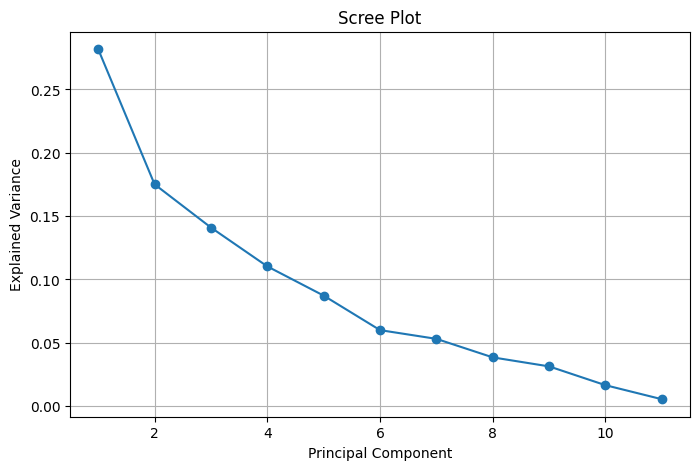

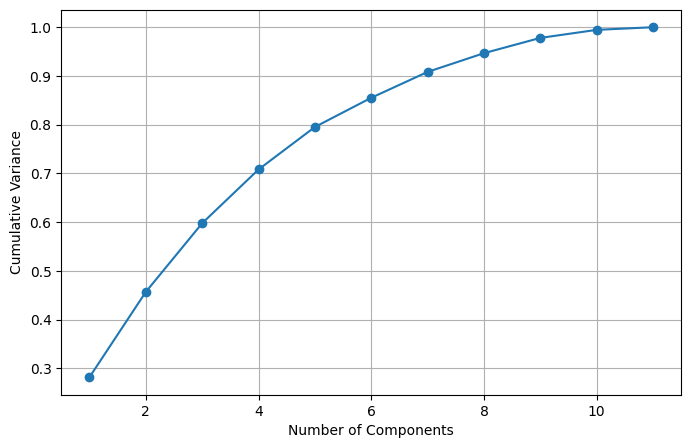

Original Shape : (1599, 11)
New Shape : (1599, 9)
Selected Components : 9
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -1.619530  0.450950 -1.774454  0.043740  0.067014  0.913921  0.161043   
1 -0.799170  1.856553 -0.911690  0.548066 -0.018392 -0.929714  1.009829   
2 -0.748479  0.882039 -1.171394  0.411021 -0.043531 -0.401473  0.539553   
3  2.357673 -0.269976  0.243489 -0.928450 -1.499149  0.131017 -0.344290   
4 -1.619530  0.450950 -1.774454  0.043740  0.067014  0.913921  0.161043   

        PC8       PC9  
0  0.282258 -0.005098  
1 -0.762587  0.520707  
2 -0.597946  0.086857  
3  0.455375 -0.091577  
4  0.282258 -0.005098  
     fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
PC1       0.489314         -0.238584     0.463632        0.146107   0.212247   
PC2      -0.110503          0.274930    -0.151791        0.272080   0.148052   
PC3      -0.123302         -0.449963     0.238247        0.101283  -0.092614   
PC4      -0

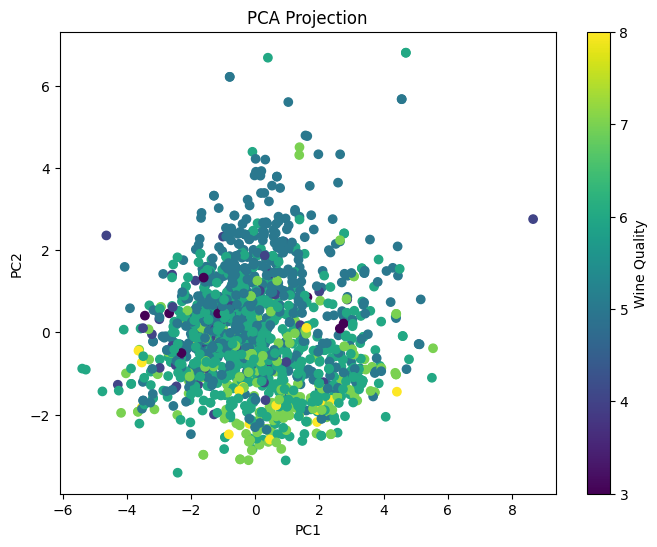

In [ ]:
# ==========================================================
# PCA (Principal Component Analysis) - Complete Code
# Dataset: Wine Quality (winequality-red.csv)
# ==========================================================

# ==========================
# 1. Import Libraries
# ==========================

# pandas -> Read and manipulate dataset
import pandas as pd

# numpy -> Mathematical operations
import numpy as np

# matplotlib -> Visualization
import matplotlib.pyplot as plt

# StandardScaler -> Scale all numerical features
from sklearn.preprocessing import StandardScaler

# PCA -> Principal Component Analysis
from sklearn.decomposition import PCA


# ==========================
# 2. Load Dataset
# ==========================

# Read csv file
df = pd.read_csv("winequality-red.csv")

# Display first 5 rows
print(df.head())


# ==========================================================
# WHY?
# We first load the dataset so that we know
# what columns and values are available.
# ==========================================================



# ==========================
# 3. Basic Information
# ==========================

print(df.shape)

print(df.info())

print(df.describe())


# ==========================================================
# WHY?
#
# shape      -> Number of rows and columns
#
# info()     -> Data types and missing values
#
# describe() -> Mean, std, min, max etc.
#
# We always understand data before applying PCA.
# ==========================================================



# ==========================
# 4. Check Missing Values
# ==========================

print(df.isnull().sum())


# ==========================================================
# WHY?
#
# PCA cannot work with missing values.
#
# If missing values exist,
# first fill or remove them.
# ==========================================================



# ==========================
# 5. Separate Features and Target
# ==========================

X = df.drop("quality", axis=1)

y = df["quality"]


# ==========================================================
# WHY?
#
# PCA works ONLY on input features (X).
#
# We never apply PCA on target variable (y).
# ==========================================================



# ==========================
# 6. Standardize Features
# ==========================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# ==========================================================
# WHY?
#
# PCA depends on variance.
#
# Large scale columns dominate PCA.
#
# Example
#
# Salary = 500000
# Age = 30
#
# Salary variance is much larger.
#
# PCA will think Salary is more important.
#
# StandardScaler makes every feature
#
# Mean = 0
# Std = 1
#
# So every feature gets equal importance.
# ==========================================================



# ==========================
# 7. Apply PCA
# ==========================

pca = PCA()

X_pca = pca.fit_transform(X_scaled)


# ==========================================================
# WHY?
#
# PCA finds new features called
#
# PC1
# PC2
# PC3
#
# that contain maximum information
# from original features.
# ==========================================================



# ==========================
# 8. Explained Variance Ratio
# ==========================

print(pca.explained_variance_ratio_)


# ==========================================================
# WHY?
#
# Shows how much information
# each Principal Component keeps.
#
# Example
#
# PC1 = 45%
# PC2 = 25%
# PC3 = 15%
#
# Higher percentage means
# more useful component.
# ==========================================================



# ==========================
# 9. Cumulative Variance
# ==========================

print(np.cumsum(pca.explained_variance_ratio_))


# ==========================================================
# WHY?
#
# We add variances one by one.
#
# Example
#
# PC1 = 45%
#
# PC1+PC2 = 70%
#
# PC1+PC2+PC3 = 85%
#
# Helps decide
# how many PCs to keep.
# ==========================================================



# ==========================
# 10. Scree Plot
# ==========================

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(pca.explained_variance_ratio_)+1),
    pca.explained_variance_ratio_,
    marker='o'
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance")
plt.title("Scree Plot")

plt.grid(True)

plt.show()


# ==========================================================
# WHY?
#
# Scree Plot helps visualize
# which components are important.
#
# Usually after some PCs,
# graph becomes flat.
#
# Remaining PCs contribute very little.
# ==========================================================



# ==========================
# 11. Cumulative Variance Plot
# ==========================

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(np.cumsum(pca.explained_variance_ratio_))+1),
    np.cumsum(pca.explained_variance_ratio_),
    marker='o'
)

plt.xlabel("Number of Components")

plt.ylabel("Cumulative Variance")

plt.grid(True)

plt.show()


# ==========================================================
# WHY?
#
# We usually keep
#
# 90%
#
# or
#
# 95%
#
# information.
#
# This graph tells
# how many PCs are enough.
# ==========================================================



# ==========================
# 12. Keep 95% Information
# ==========================

pca = PCA(n_components=0.95)

X_new = pca.fit_transform(X_scaled)


# ==========================================================
# WHY?
#
# PCA automatically selects
# minimum PCs
#
# that preserve
#
# 95%
#
# information.
# ==========================================================



# ==========================
# 13. Shape Before and After
# ==========================

print("Original Shape :", X_scaled.shape)

print("New Shape :", X_new.shape)


# ==========================================================
# WHY?
#
# Compare dimensions.
#
# Example
#
# Before
#
# (1599,11)
#
# After
#
# (1599,6)
#
# PCA reduced dimensions.
# ==========================================================



# ==========================
# 14. Number of Components
# ==========================

print("Selected Components :", pca.n_components_)


# ==========================================================
# WHY?
#
# Shows
#
# How many PCs
#
# were needed
#
# to preserve
#
# 95%
#
# information.
# ==========================================================



# ==========================
# 15. Create PCA DataFrame
# ==========================

pca_df = pd.DataFrame(

    X_new,

    columns=[f"PC{i}" for i in range(1,pca.n_components_+1)]

)

print(pca_df.head())


# ==========================================================
# WHY?
#
# PCA output is NumPy array.
#
# DataFrame makes it easier
# to view and analyze.
# ==========================================================



# ==========================
# 16. PCA Component Weights
# ==========================

loadings = pd.DataFrame(

    pca.components_,

    columns=X.columns,

    index=[f"PC{i}" for i in range(1,pca.n_components_+1)]

)

print(loadings)


# ==========================================================
# WHY?
#
# Shows how much each
# original feature contributes
# to every Principal Component.
#
# Large absolute value
#
# = High contribution.
# ==========================================================



# ==========================
# 17. Visualize First Two PCs
# ==========================

plt.figure(figsize=(8,6))

plt.scatter(

    pca_df["PC1"],

    pca_df["PC2"],

    c=y,

    cmap="viridis"

)

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.title("PCA Projection")

plt.colorbar(label="Wine Quality")

plt.show()


# ==========================================================
# WHY?
#
# Original dataset has
#
# 11 dimensions.
#
# Impossible to visualize.
#
# PCA converts
#
# 11D
#
# into
#
# 2D
#
# so we can see
# patterns and clusters.
# ==========================================================